## **Chat Model**

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(
    model_provider="groq",
    model="qwen/qwen3-32b",
    temperature=0.1
)

In [4]:
llm.invoke("Test line")

AIMessage(content='<think>\nOkay, the user sent "Test line". Let me think about how to respond. First, I need to acknowledge their message. Since it\'s a test line, maybe they\'re checking if the system is working. I should keep the response simple and friendly. Let me confirm that I received their message and offer assistance. Maybe say something like, "Hello! It looks like you\'re testing the waters. How can I assist you today?" That should be clear and open-ended, inviting them to ask for help if needed. I should avoid any technical jargon and keep it conversational. Let me make sure there are no typos and that the tone is approachable. Yeah, that should work.\n</think>\n\nHello! It looks like you\'re testing the waters. How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 10, 'total_tokens': 176, 'completion_time': 0.320130427, 'prompt_time': 0.000217867, 'queue_time': 0.04614548, 'total_time': 0.3203482

## **Tools Calling**

In [5]:
from langchain.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and sand an email."""
    return f"Email sand to {to} with {subject} and content: {content}"

In [6]:
type(write_email)

langchain_core.tools.structured.StructuredTool

In [7]:
write_email.args

{'to': {'title': 'To', 'type': 'string'},
 'subject': {'title': 'Subject', 'type': 'string'},
 'content': {'title': 'Content', 'type': 'string'}}

## **Bind Tools**

In [13]:
model_with_tools = llm.bind_tools([write_email], tool_choice="any", parallel_tool_calls=False)

output = model_with_tools.invoke("Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'")

In [32]:
args = output.tool_calls[0]
args

{'name': 'write_email',
 'args': {'content': "Dear D,\n\nI hope this message finds you well. I wanted to confirm my attendance for tomorrow's meeting and express that I'm fully prepared to discuss the necessary topics. Please let me know if there are any specific items you'd like me to focus on during the meeting.\n\nLooking forward to it.\n\nBest regards,\nMd Al Amin",
  'subject': "Tomorrow's Meeting Confirmation",
  'to': 'D'},
 'id': 'stszng6hm',
 'type': 'tool_call'}

In [33]:
args = output.tool_calls[0]["args"]
args

{'content': "Dear D,\n\nI hope this message finds you well. I wanted to confirm my attendance for tomorrow's meeting and express that I'm fully prepared to discuss the necessary topics. Please let me know if there are any specific items you'd like me to focus on during the meeting.\n\nLooking forward to it.\n\nBest regards,\nMd Al Amin",
 'subject': "Tomorrow's Meeting Confirmation",
 'to': 'D'}

## **Execute the tools**

In [16]:
result = write_email.invoke(args)
print(result)

Email sand to D with Tomorrow's Meeting Confirmation and content: Dear D,

I hope this message finds you well. I wanted to confirm my attendance for tomorrow's meeting and express that I'm fully prepared to discuss the necessary topics. Please let me know if there are any specific items you'd like me to focus on during the meeting.

Looking forward to it.

Best regards,
Md Al Amin


## **LangGraph**

In [17]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateSchema(TypedDict):
    request: str
    email: str
    

In [21]:
def write_email_node(state: StateSchema) -> StateSchema:
    request = state["request"]
    output = model_with_tools.invoke(request)
    args = output.tool_calls[0]["args"]
    email = write_email.invoke(args)

    return {
        "email": email
    }

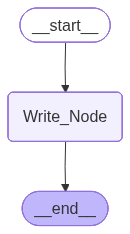

In [22]:
workflow = StateGraph(StateSchema)
workflow.add_node("Write_Node", write_email_node)

workflow.add_edge(START, "Write_Node")
workflow.add_edge("Write_Node", END)

app = workflow.compile()
app

In [23]:
app.invoke(
    {
        "request": "Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'"
    }
)

{'request': "Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'",
 'email': "Email sand to D with Confirmation for Tomorrow's Meeting and content: Dear D, I hope this message finds you well. I am writing to confirm my attendance for tomorrow's meeting. I look forward to discussing the agenda items. Please let me know if there's anything else I should prepare. Best regards, Md Al Amin"}

## **Dynamic Tools Call**

In [51]:
from langgraph.graph import START, END, MessagesState, StateGraph


def llm_call(state: MessagesState) -> MessagesState:
    print("--->LLM Call<----")
    "llm call executions"
    request = state["messages"]

    response = model_with_tools.invoke(request)

    return {
        "messages": [response]
    }

In [62]:
def tool_call_node(state: MessagesState):
    print("--->tool call<-----")
    tool_calls = state['messages'][-1].tool_calls

    result = []
    for tool_call in tool_calls:
        print("-----------tool args-----------")
        print(tool_call['args'])
        print("---------args end--------------")
        observation = write_email.invoke(tool_call["args"])

        result.append(
            {
                "role": "tool",
                "content": observation,
                "tool_call_id": tool_call["id"]
            }
        )
    return {
        "messages": result
    }

In [63]:
from typing import Literal
def should_continue(state: MessagesState) -> Literal["run_tool", END]:
    """Route to tool handler, or end if done tool called"""
    messages = state["messages"]
    last_messages = messages[-1]

    if last_messages.tool_calls:
        return "run_tool"
    return END



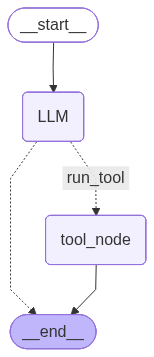

In [68]:
workflow = StateGraph(MessagesState)
workflow.add_node("LLM", llm_call)
workflow.add_node("tool_node", tool_call_node)


workflow.add_edge(START, "LLM")
workflow.add_conditional_edges(
    "LLM",
    should_continue,
    {
        "run_tool": "tool_node",
        END: END
    }
)
# workflow.add_edge("tool_node", "LLM")

app = workflow.compile()
app

In [71]:
result = app.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'"
            }
        ]
    }
)

for m in result["messages"]:
    m.pretty_print()

--->LLM Call<----
--->tool call<-----
-----------tool args-----------
{'content': "Dear D, I hope this email finds you well. I wanted to confirm my availability for tomorrow's meeting and express my readiness to discuss the necessary topics. Please let me know if there are any specific points you'd like me to prepare in advance. Best regards, Md Al Amin", 'subject': "Confirmation of Tomorrow's Meeting", 'to': 'D'}
---------args end--------------
================================ Human Message =================================

Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'
================================== Ai Message ==================================
Tool Calls:
  write_email (m3drxz258)
 Call ID: m3drxz258
  Args:
    content: Dear D, I hope this email finds you well. I wanted to confirm my availability for tomorrow's meeting and express my readiness to discuss the necessary topics. Please let me know if there are any specific points yo

## **Build in create React Agent**

In [73]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided"
)

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'"
            }
        ]
    }
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Draft a response to my boss tomorrow's meeting and his name is 'D' and my name is 'Md Al Amin'
================================== Ai Message ==================================
Tool Calls:
  write_email (j2n05j417)
 Call ID: j2n05j417
  Args:
    content: Dear D,

I hope this message finds you well. I wanted to confirm my attendance for tomorrow's meeting and express my enthusiasm to discuss the key points on the agenda. Please let me know if there are any specific materials or preparations I should prepare in advance.

Looking forward to our discussion.

Best regards,
Md Al Amin
    subject: Confirmation of Attendance for Tomorrow's Meeting
    to: D
================================= Tool Message =================================
Name: write_email

Email sand to D with Confirmation of Attendance for Tomorrow's Meeting and content: Dear D,

I hope this message finds you well. I wanted to confirm my attenda

## **Persistence**

In [74]:
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided",
    checkpointer=InMemorySaver()
)

config = {
    "configurable": {
        "thread_id": "1"
    }
}
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What are the good practice to writing the email?"
            }
        ]
    },
    config=config
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the good practice to writing the email?
================================== Ai Message ==================================

Here are some key best practices for writing effective emails:

1. **Clear Subject Line**: Summarize the purpose concisely (e.g., "Project Update - Q3 2023").
2. **Professional Greeting**: Use "Hi [Name]" or "Dear [Title/Name]".
3. **Direct Opening**: State the purpose in the first paragraph.
4. **Concise Structure**: Use short paragraphs, bullet points for lists, and logical flow.
5. **Tone**: Match formality to the audience (professional yet approachable).
6. **Call to Action**: Clearly state what you need from the recipient.
7. **Closing**: Use "Best regards" or "Sincerely", followed by your full name/contact info.
8. **Proofread**: Check for typos, grammar, and clarity before sending.

Would you like me to draft an email for you using these guidelines?


In [75]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Grate, let's use that best practices and craft a response to my boss confirming that i want to attend Interrupt"
            }
        ]
    },
    config=config
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the good practice to writing the email?
================================== Ai Message ==================================

Here are some key best practices for writing effective emails:

1. **Clear Subject Line**: Summarize the purpose concisely (e.g., "Project Update - Q3 2023").
2. **Professional Greeting**: Use "Hi [Name]" or "Dear [Title/Name]".
3. **Direct Opening**: State the purpose in the first paragraph.
4. **Concise Structure**: Use short paragraphs, bullet points for lists, and logical flow.
5. **Tone**: Match formality to the audience (professional yet approachable).
6. **Call to Action**: Clearly state what you need from the recipient.
7. **Closing**: Use "Best regards" or "Sincerely", followed by your full name/contact info.
8. **Proofread**: Check for typos, grammar, and clarity before sending.

Would you like me to draft an email for you using these guidelines?
====================

## ***Interrupt***

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)

In [4]:
config = {
    "configurable": {
        "thread_id": "chat_1"
    }
}
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Grate, let's use that best practices and craft a response to my boss confirming that i want to attend Interrupt"
            }
        ]
    },
    config=config
)

# for m in result["messages"]:
#     m.pretty_print()

---Step 1---
---human_feedback---
